In [52]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [53]:
from scipy.io import arff

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import joblib

In [54]:
data, meta = arff.loadarff("dataset.arff")
df = pd.DataFrame(data)

In [55]:

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [56]:
df['Class'].value_counts(normalize=True) * 100

Class
0.0    99.827251
1.0     0.172749
Name: proportion, dtype: float64

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"].astype(int) 

In [58]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

In [59]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

In [60]:
if len(categorical_cols) > 0:
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])
else:
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols)
    ])

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [63]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced"
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=0,
        auto_class_weights="Balanced"
    )
}

In [64]:
trained_models = {}
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = evaluate_model(y_test, y_pred, y_prob)
    trained_models[name] = pipe

    print(name, results[name])

Training LogisticRegression...
LogisticRegression {'accuracy': 0.9991573329588147, 'precision': 0.8289473684210527, 'recall': 0.6428571428571429, 'f1': 0.7241379310344828, 'roc_auc': np.float64(0.9592479155421314)}
Training DecisionTree...
DecisionTree {'accuracy': 0.9991397773954567, 'precision': 0.7525773195876289, 'recall': 0.7448979591836735, 'f1': 0.7487179487179487, 'roc_auc': np.float64(0.8722379497662881)}
Training RandomForest...
RandomForest {'accuracy': 0.9995259997893332, 'precision': 0.961038961038961, 'recall': 0.7551020408163265, 'f1': 0.8457142857142858, 'roc_auc': np.float64(0.9571877727596384)}
Training XGBoost...
XGBoost {'accuracy': 0.9995259997893332, 'precision': 0.9080459770114943, 'recall': 0.8061224489795918, 'f1': 0.8540540540540541, 'roc_auc': np.float64(0.9769794454078762)}
Training LightGBM...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004260 s

In [75]:
results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.999157,0.828947,0.642857,0.724138,0.959248
DecisionTree,0.999140,0.752577,0.744898,0.748718,0.872238
RandomForest,0.999526,0.961039,0.755102,0.845714,0.957188
XGBoost,0.999526,0.908046,0.806122,0.854054,0.976979
LightGBM,0.999508,0.857143,0.857143,0.857143,0.977775
CatBoost,0.999175,0.710744,0.877551,0.785388,0.977896


In [65]:
results_df = pd.DataFrame(results).T
best_model_name = results_df["roc_auc"].idxmax()

print("BEST MODEL:", best_model_name)

BEST MODEL: CatBoost


In [66]:
param_grid = {

    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1],
        "model__solver": ["lbfgs", "liblinear"],
        "model__class_weight": ["balanced"]
    },

    "DecisionTree": {
        "model__max_depth": [10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5],
        "model__class_weight": ["balanced"]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__class_weight": ["balanced"]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [31, 50, 100]
    },

    "CatBoost": {
        "model__iterations": [100, 200, 300],
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1]
    }
}

In [67]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

search = RandomizedSearchCV(
    pipeline,
    param_grid[best_model_name],
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

{'model__learning_rate': 0.01, 'model__iterations': 300, 'model__depth': 8}


In [68]:
voting = VotingClassifier(
    estimators=[
        ("xgb", trained_models["XGBoost"].named_steps["model"]),
        ("lgb", trained_models["LightGBM"].named_steps["model"]),
        ("rf", trained_models["RandomForest"].named_steps["model"])
    ],
    voting="soft"
)

voting_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", voting)
])

voting_pipe.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model',...
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=300,
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             random_state=42, ...)),
                                              ('lgb',
                                               LGBMClassifier(class_weight='balanced',
                                                              learning_rate=0.05,
                                                              n_estimators=300)),
                                              ('rf',
                                               RandomForestClassifier(class_weight='balanced',
                                                                      n_estimators=200,
                                                                      random_state=42))],
                                  voting='soft'))])

In [69]:
stacking = StackingClassifier(
    estimators=[
        ("xgb", trained_models["XGBoost"].named_steps["model"]),
        ("rf", trained_models["RandomForest"].named_steps["model"]),
        ("lgb", trained_models["LightGBM"].named_steps["model"])
    ],
    final_estimator=LogisticRegression(),
    stack_method="predict_proba"
)

stack_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacking)
])

stack_pipe.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 316, number of negative: 181960
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025016 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model',...
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=300,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=42, ...)),
                                                ('rf',
                                                 RandomForestClassifier(class_weight='balanced',
                                                                        n_estimators=200,
                                                                        random_state=42)),
                                                ('lgb',
                                                 LGBMClassifier(class_weight='balanced',
                                                                learning_rate=0.05,
                                                                n_estimators=300))],
                                    final_estimator=LogisticRegression(),
                                    stack_method='predict_proba'))])

In [70]:
smote_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTETomek(random_state=42)),
    ("model", models[best_model_name])
])

smote_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('smote', SMOTETomek(random_state=42)),
                ('model',
                 CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=300, learning_rate=0.05, verbose=0))])

In [71]:
def evaluate_pipeline(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    return evaluate_model(y_test, y_pred, y_prob)

In [72]:
final_results = {
    "Best_Tuned": evaluate_pipeline(best_model, X_test, y_test),
    "Voting": evaluate_pipeline(voting_pipe, X_test, y_test),
    "Stacking": evaluate_pipeline(stack_pipe, X_test, y_test),
    "SMOTE": evaluate_pipeline(smote_model, X_test, y_test)
}

pd.DataFrame(final_results).T.sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc
SMOTE,0.997437,0.391892,0.887755,0.543750,0.982091
Best_Tuned,0.998139,0.477778,0.877551,0.618705,0.980702
Stacking,0.999561,0.939759,0.795918,0.861878,0.977423
Voting,0.999561,0.910112,0.826531,0.866310,0.977381


In [73]:
best_final_model = stack_pipe 
y_pred = best_final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56859     5]
 [   20    78]]


In [76]:
best_shap_model = trained_models["CatBoost"]

In [77]:
X_transformed = best_shap_model.named_steps["preprocessor"].transform(X_test)

feature_names = (
    best_shap_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of features:", len(feature_names))

Number of features: 30


In [78]:
cat_model = best_shap_model.named_steps["model"]

print(type(cat_model))

<class 'catboost.core.CatBoostClassifier'>


In [87]:
fraud_df = df[df['Class'] == 1].copy()

In [90]:
fraud_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1.0
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1.0
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1.0
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1.0
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1.0
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1.0
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1.0
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1.0


In [88]:
real_df = df[df['Class'] == 0].copy()

In [91]:
real_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0.0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0.0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0.0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0.0


In [79]:
explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_transformed)

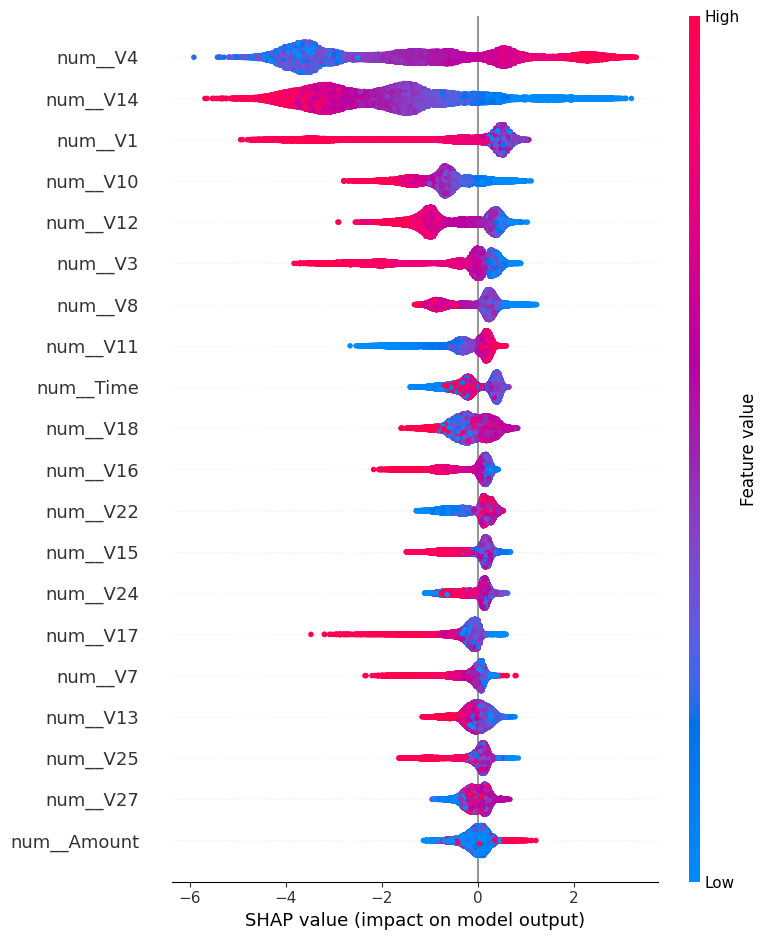

In [81]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

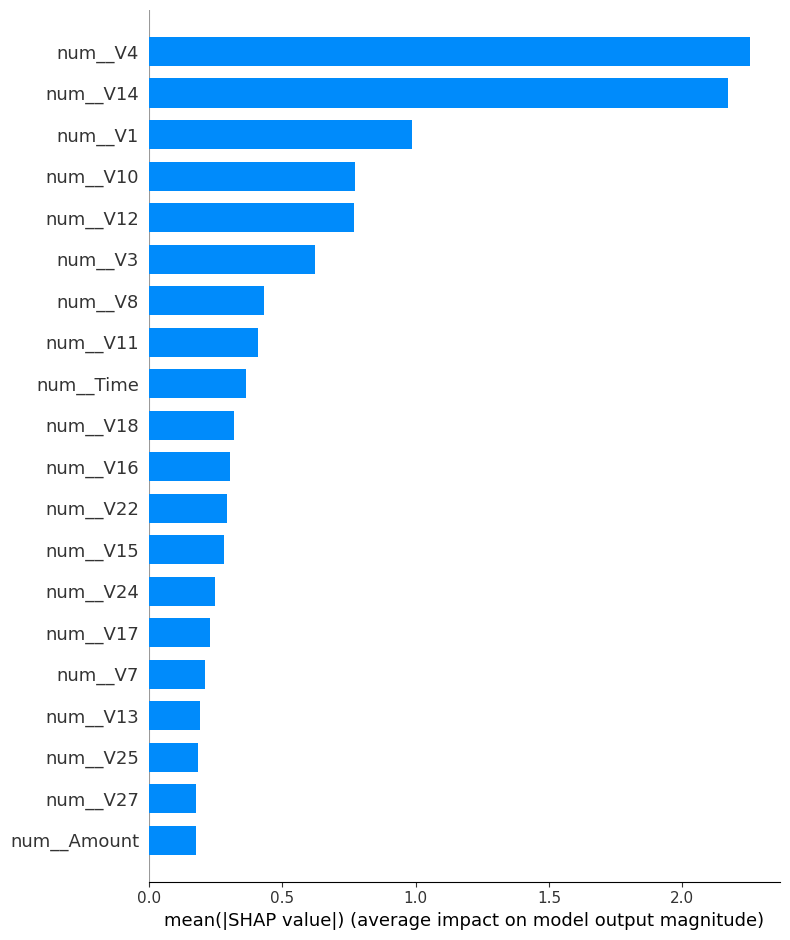

In [82]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [83]:
importance = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

shap_importance = shap_importance.sort_values(
    "Importance",
    ascending=False
)

shap_importance.head(15)

,Feature,Importance
4,num__V4,2.253770
14,num__V14,2.171501
1,num__V1,0.985991
10,num__V10,0.772293
12,num__V12,0.769748
3,num__V3,0.623900
8,num__V8,0.430380
11,num__V11,0.407725
0,num__Time,0.363391
18,num__V18,0.317885


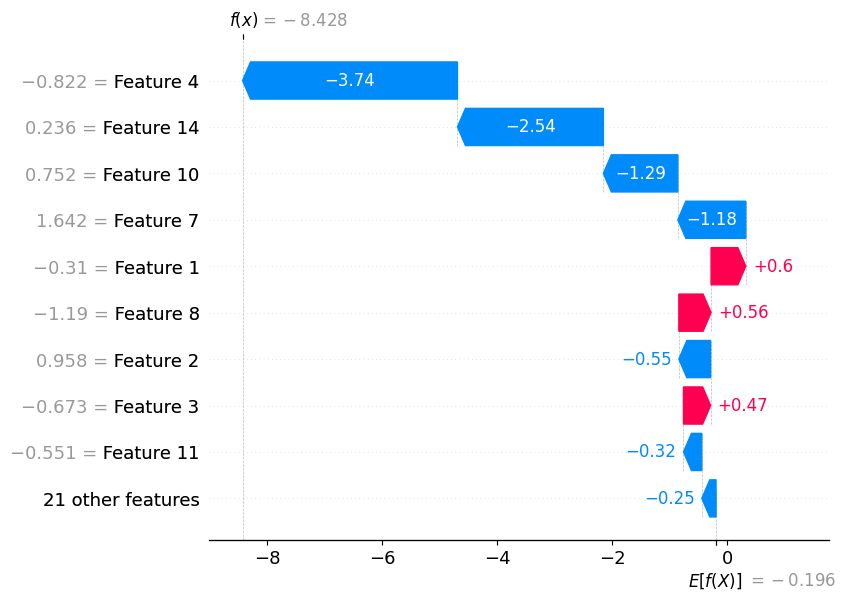

In [84]:
shap_exp = explainer(X_transformed)

shap.plots.waterfall(shap_exp[0])

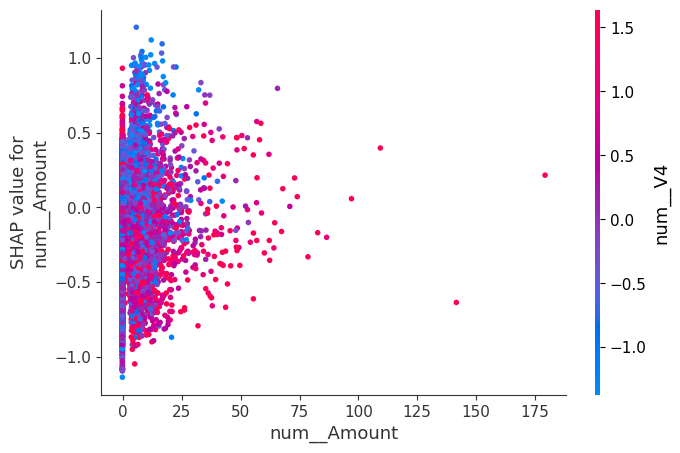

In [85]:
shap.dependence_plot(
    "num__Amount",
    shap_values,
    X_transformed,
    feature_names=feature_names
)